In [ ]:
# 1) Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler # Estandarización de variables numéricas
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.metrics import f1_score

In [ ]:
df = pd.read_csv("census.csv")
df

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,33,Private,Bachelors,13.0,Never-married,Prof-specialty,Own-child,White,Male,0.0,0.0,40.0,United-States,<=50K
45218,39,Private,Bachelors,13.0,Divorced,Prof-specialty,Not-in-family,White,Female,0.0,0.0,36.0,United-States,<=50K
45219,38,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K
45220,44,Private,Bachelors,13.0,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455.0,0.0,40.0,United-States,<=50K


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              45222 non-null  int64  
 1   workclass        45222 non-null  object 
 2   education_level  45222 non-null  object 
 3   education-num    45222 non-null  float64
 4   marital-status   45222 non-null  object 
 5   occupation       45222 non-null  object 
 6   relationship     45222 non-null  object 
 7   race             45222 non-null  object 
 8   sex              45222 non-null  object 
 9   capital-gain     45222 non-null  float64
 10  capital-loss     45222 non-null  float64
 11  hours-per-week   45222 non-null  float64
 12  native-country   45222 non-null  object 
 13  income           45222 non-null  object 
dtypes: float64(4), int64(1), object(9)
memory usage: 4.8+ MB


In [ ]:
is_null = df.isna().any() #ISNA -> VER SI NO ES NUM OSEA VALOR FALTANTE.
is_null[is_null]

,0


In [ ]:
# Comprobación de la existencia de valores infinitos
is_inf = df.isin([np.inf, -np.inf]).any()
is_inf[is_inf]

,0


In [ ]:
print(df['sex'].unique())

[' Male' ' Female']


In [ ]:
# Select relevant columns
df_selected = df[['age', 'education-num', 'sex', 'hours-per-week', 'income']].copy()
# Convert 'income' to numerical (0 for <=50K, 1 for >50K) using map
df_selected['income'] = df_selected['income'].map({'<=50K': 0, '>50K': 1})

# Convert 'sex' to numerical (0 for Female, 1 for Male)
df_selected['sex'] = df_selected['sex'].str.strip().str.capitalize()
df_selected['sex'] = df_selected['sex'].map({'Male': 0, 'Female': 1})

df_selected

,age,education-num,sex,hours-per-week,income
0,39,13.0,0,40.0,0
1,50,13.0,0,13.0,0
2,38,9.0,0,40.0,0
3,53,7.0,0,40.0,0
4,28,13.0,1,40.0,0
...,...,...,...,...,...
45217,33,13.0,0,40.0,0
45218,39,13.0,1,36.0,0
45219,38,13.0,0,50.0,0
45220,44,13.0,0,40.0,0


In [ ]:
# Define features (X) and target (y)
X = df_selected[['age', 'education-num', 'sex', 'hours-per-week']]
y = df_selected['income']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data splitting complete.")
print(f"Training set shape (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Testing set shape (X_test, y_test): {X_test.shape}, {y_test.shape}")

Data splitting complete.
Training set shape (X_train, y_train): (36177, 4), (36177,)
Testing set shape (X_test, y_test): (9045, 4), (9045,)


In [ ]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete.")

Feature scaling complete.


In [ ]:
# Train a Support Vector Machine model
svm_model = SVC(kernel='linear', random_state=42)  # Using a linear kernel for simplicity
svm_model.fit(X_train_scaled, y_train)


SVC(kernel='linear', random_state=42)

In [ ]:
# Make predictions
y_pred = svm_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the SVM model: {accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy of the SVM model: 0.7926

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.95      0.87      6745
           1       0.70      0.33      0.44      2300

    accuracy                           0.79      9045
   macro avg       0.75      0.64      0.66      9045
weighted avg       0.78      0.79      0.76      9045


Confusion Matrix:
[[6419  326]
 [1550  750]]


In [ ]:
from sklearn.metrics import f1_score

# Make predictions using the trained model on the scaled test data
y_pred = svm_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the SVM model: {accuracy:.4f}")

# Calculate the F1-score
f1 = f1_score(y_test, y_pred)

print(f"F1-score of the SVM model: {f1:.4f}")

Accuracy of the SVM model: 0.7926
F1-score of the SVM model: 0.4443


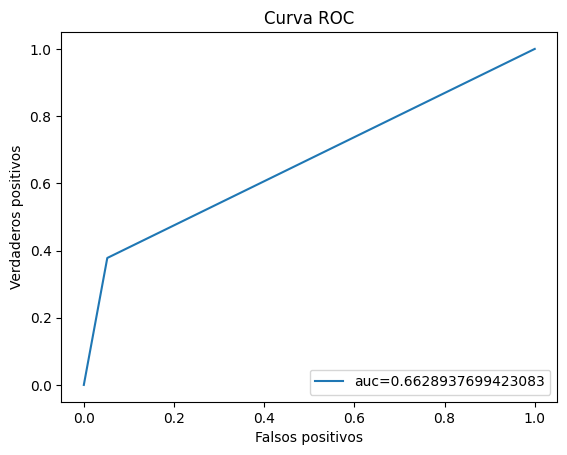

In [ ]:
from sklearn import metrics

# Calculate the ROC curve
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)

# Calculate the AUC
auc = metrics.roc_auc_score(y_test, y_pred)

# Plot the ROC curve
plt.plot(fpr,tpr,label="auc="+str(auc))
plt.legend(loc=4)
plt.xlabel('Falsos positivos')
plt.ylabel('Verdaderos positivos')
plt.title('Curva ROC')
plt.show()

In [ ]:
# Train a Support Vector Machine model
svm_model = SVC(kernel='rbf', random_state=42) # Usa kernel gausiano
svm_model.fit(X_train_scaled, y_train)
# Make predictions
y_pred = svm_model.predict(X_test_scaled)
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the SVM model: {accuracy:.4f}")
# Make predictions using the trained model on the scaled test data
y_pred = svm_model.predict(X_test_scaled)

# Calculate the F1-score
f1 = f1_score(y_test, y_pred)

print(f"F1-score of the SVM model: {f1:.4f}")

Accuracy of the SVM model: 0.8030
F1-score of the SVM model: 0.4938


In [ ]:
# Make predictions
y_pred = svm_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the SVM model: {accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy of the SVM model: 0.8030

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.95      0.88      6745
           1       0.71      0.38      0.49      2300

    accuracy                           0.80      9045
   macro avg       0.76      0.66      0.69      9045
weighted avg       0.79      0.80      0.78      9045


Confusion Matrix:
[[6394  351]
 [1431  869]]


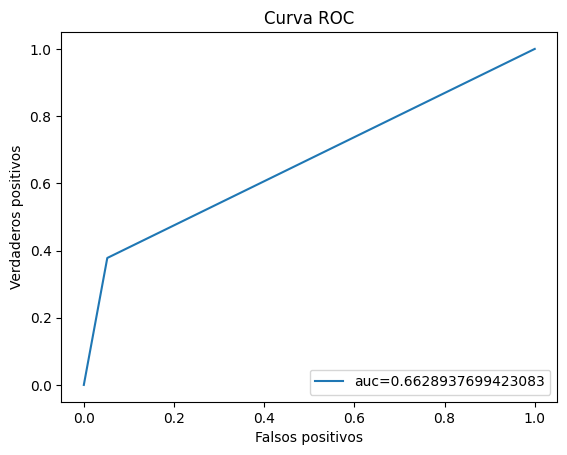

In [ ]:
from sklearn import metrics

# Calculate the ROC curve
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)

# Calculate the AUC
auc = metrics.roc_auc_score(y_test, y_pred)

# Plot the ROC curve
plt.plot(fpr,tpr,label="auc="+str(auc))
plt.legend(loc=4)
plt.xlabel('Falsos positivos')
plt.ylabel('Verdaderos positivos')
plt.title('Curva ROC')
plt.show()

In [ ]:
# Crear un nuevo punto de datos para el individuo
# edad=30, education-num=10, sexo=Hombre (codificado como 1), horas-por-semana=40
new_individual_data = pd.DataFrame({
    'age': [30],
    'education-num': [10],
    'sex': [1],  # Hombre está codificado como 1
    'hours-per-week': [40]
})

# Escalar el nuevo punto de datos usando el mismo escalador ajustado en los datos de entrenamiento
new_individual_scaled = scaler.transform(new_individual_data)

# Hacer una predicción usando el modelo SVM entrenado
prediction = svm_model.predict(new_individual_scaled)

# Interpretar la predicción
if prediction[0] == 1:
    print("Según el modelo, se predice que este individuo ganará más de $50,000 por año.")
else:
    print("Según el modelo, se predice que este individuo ganará menos o igual a $50,000 por año.")

Según el modelo, se predice que este individuo ganará menos o igual a $50,000 por año.
